<a href="https://colab.research.google.com/github/CameronKoP4/earthquake-dataset-analysis/blob/main/Earthquakes_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url = "https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Earthquakes/earthquakes.csv"

df = pd.read_csv(url)

df.head()

,time,latitude,longitude,depth,mag,magType,net,id,place,type
0,2017-02-21 01:41:11.800000+00:00,-20.3521,-177.7955,512.760,4.4,mb,us,us1000860s,"283 km WNW of Haveluloto, Tonga",earthquake
1,2020-06-10 12:58:33.535000+00:00,69.3927,-143.9529,12.500,3.1,ml,ak,ak0207g4jxgn,"83 km S of Kaktovik, Alaska",earthquake
2,2020-11-29 01:02:57.577000+00:00,3.7184,126.3073,122.480,4.2,mb,us,us7000cmmz,"208 km SSE of Sarangani, Philippines",earthquake
3,2015-12-11 22:07:37.420000+00:00,-19.7988,-69.2959,107.450,4.3,mb,us,us20004hcx,"100 km ENE of Iquique, Chile",earthquake
4,2023-07-23 12:33:29.354000+00:00,-8.6271,111.1186,96.623,5.1,mb,us,us7000khss,"Java, Indonesia",earthquake


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178752 entries, 0 to 178751
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   time       178752 non-null  object 
 1   latitude   178752 non-null  float64
 2   longitude  178752 non-null  float64
 3   depth      178752 non-null  float64
 4   mag        178752 non-null  float64
 5   magType    178751 non-null  object 
 6   net        178752 non-null  object 
 7   id         178752 non-null  object 
 8   place      178752 non-null  object 
 9   type       178752 non-null  object 
dtypes: float64(4), object(6)
memory usage: 13.6+ MB


In [ ]:
df.columns

Index(['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'net', 'id',
       'place', 'type'],
      dtype='object')

In [ ]:
df.describe()

,latitude,longitude,depth,mag
count,178752.000000,178752.000000,178752.000000,178752.000000
mean,10.310539,-0.890781,75.676687,4.234366
std,31.316945,127.664178,128.898539,0.627656
min,-82.883700,-179.999700,-3.740000,3.000000
25%,-15.645975,-116.513708,10.000000,4.000000
50%,12.926750,-25.651750,23.600000,4.300000
75%,36.553775,128.116150,75.010000,4.600000
max,87.386000,179.999400,686.390000,8.300000


In [ ]:
df.shape

(178752, 10)

In [ ]:
df.dtypes

,0
time,object
latitude,float64
longitude,float64
depth,float64
mag,float64
magType,object
net,object
id,object
place,object
type,object


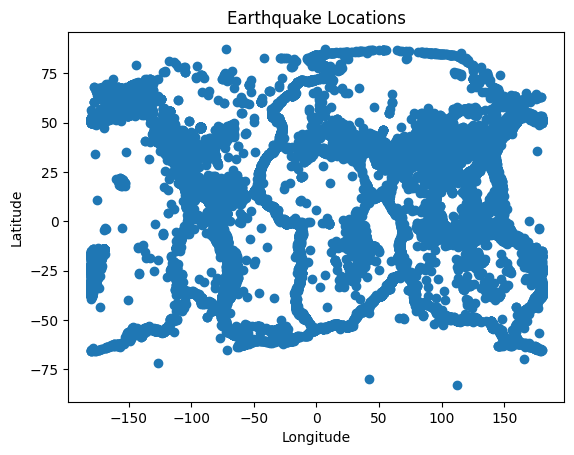

In [ ]:
plt.scatter(df['longitude'], df['latitude'])

plt.title("Earthquake Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()


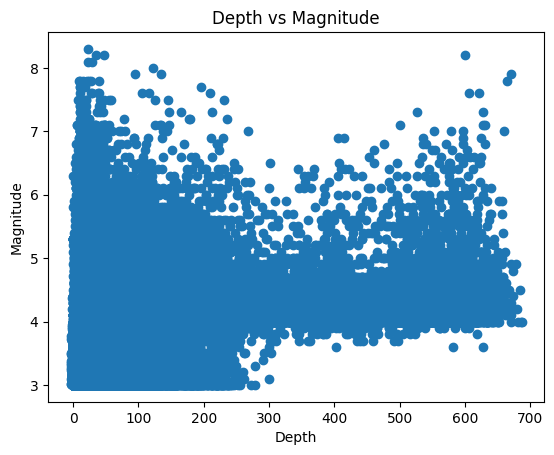

In [ ]:
plt.scatter(df['depth'], df['mag'])

plt.title("Depth vs Magnitude")
plt.xlabel("Depth")
plt.ylabel("Magnitude")

plt.show()

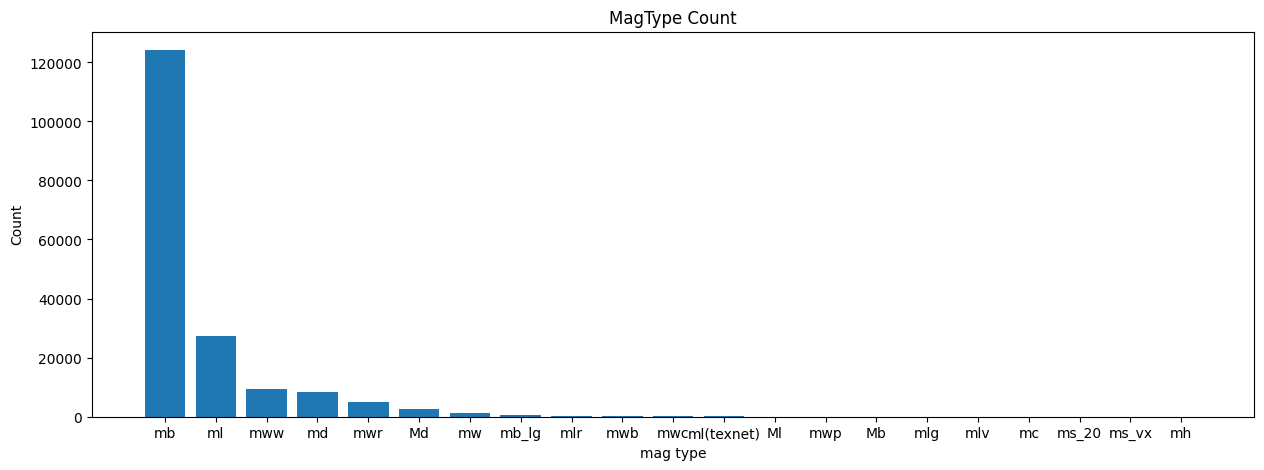

In [ ]:
magtype_counts = df["magType"].value_counts()

plt.figure(figsize=(15, 5))
plt.bar(magtype_counts.index, magtype_counts.values)

plt.title("MagType Count")
plt.xlabel("mag type")
plt.ylabel("Count")

plt.show()

In [ ]:
df.isnull().sum()

,0
time,0
latitude,0
longitude,0
depth,0
mag,0
magType,1
net,0
id,0
place,0
type,0


In [ ]:
df['magType'] = df['magType'].fillna("Unknown")

df.isnull().sum()

,0
time,0
latitude,0
longitude,0
depth,0
mag,0
magType,0
net,0
id,0
place,0
type,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178752 entries, 0 to 178751
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   time       178752 non-null  object 
 1   latitude   178752 non-null  float64
 2   longitude  178752 non-null  float64
 3   depth      178752 non-null  float64
 4   mag        178752 non-null  float64
 5   magType    178752 non-null  object 
 6   net        178752 non-null  object 
 7   id         178752 non-null  object 
 8   place      178752 non-null  object 
 9   type       178752 non-null  object 
dtypes: float64(4), object(6)
memory usage: 13.6+ MB


In [ ]:
df.describe()

,latitude,longitude,depth,mag
count,178752.000000,178752.000000,178752.000000,178752.000000
mean,10.310539,-0.890781,75.676687,4.234366
std,31.316945,127.664178,128.898539,0.627656
min,-82.883700,-179.999700,-3.740000,3.000000
25%,-15.645975,-116.513708,10.000000,4.000000
50%,12.926750,-25.651750,23.600000,4.300000
75%,36.553775,128.116150,75.010000,4.600000
max,87.386000,179.999400,686.390000,8.300000


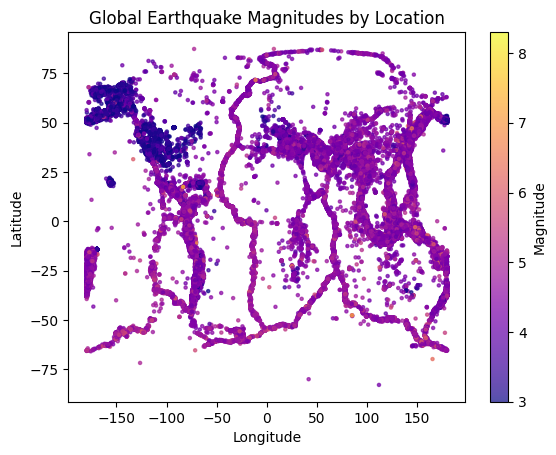

In [ ]:
scatter = plt.scatter(df['longitude'], df['latitude'], c = df["mag"], cmap="plasma",s=5, alpha=0.7)

plt.title("Global Earthquake Magnitudes by Location")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

cbar = plt.colorbar(scatter)
cbar.set_label("Magnitude")

plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

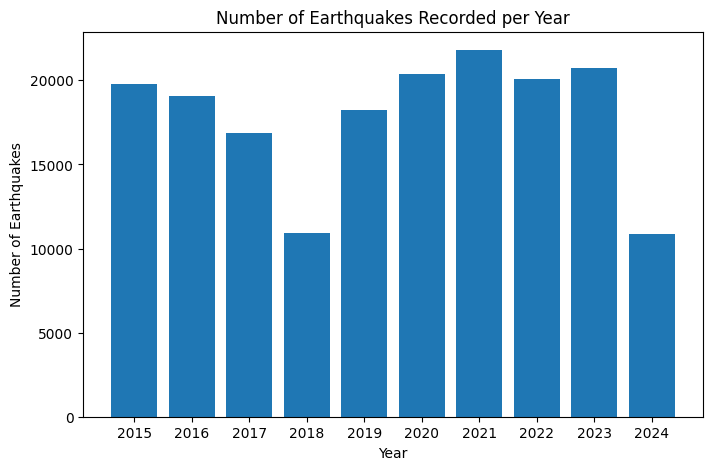

In [8]:
df["time"] = pd.to_datetime(df["time"], format = 'ISO8601')
df["year"] = df["time"].dt.year

year_counts = df["year"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(year_counts.index, year_counts.values)

plt.xlabel("Year")
plt.ylabel("Number of Earthquakes")
plt.title("Number of Earthquakes Recorded per Year")
plt.xticks(year_counts.index)

plt.show